In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline           # 스케일링 + 모델을 한번에 연결하는 파이프라인 기능을 위함
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier         # 여러 모델을 결합하는 Voting 앙상블 모델을 사용하기 위함

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [21]:
# 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names

In [8]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [15]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
# 개별 모델 정의(SVM, KNN, RandomForest)

# SVM
svm_clf = make_pipeline(   
    StandardScaler(),      # 데이터 정규화 (SVM은 거리 기반이라 스케일 중요)
    SVC(
        C=1.0,             # 규제 강도 (클수록 학습 데이터에 더 맞춤 → 과적합 가능성 ↑)
        kernel="rbf",      # 비선형 커널 (복잡한 패턴 학습)
        probability=True,  # 확률 출력 가능 (soft voting에 필요)
        random_state=42
    )
)  # make_pipeline: 전처리 + 모델을 순서대로 묶어서 한 번에 처리

# KNN
knn_clf = make_pipeline(   
    StandardScaler(),   # 거리 기반이라 스케일 필요
    KNeighborsClassifier(n_neighbors=5)  # 가장 가까운 5개 이웃 기준으로 분류
)

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100,   # 트리 개수
    max_depth=None,     # 깊이 제한 없음
    random_state=42
)

# 3개의 모델을 soft voting 방식으로 결합
voting_clf = VotingClassifier(
    estimators=[('svm', svm_clf), ('knn', knn_clf), ('rf', rf_clf)],  # 모델 리스트
    voting='soft',       # 확률 평균으로 최종 예측
    weights=[1, 1, 2]    # RandomForest 비중을 더 크게 설정 (svm=1, knn=1, rf=2)
)

In [22]:
# 모델 학습
svm_clf.fit(X_train, y_train)
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
voting_clf.fit(X_train, y_train)

,estimators,"[('svm', ...), ('knn', ...), ...]"
,voting,'soft'
,weights,"[1, 1, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'


In [23]:
# 모델 평가 및 정확도 출력
y_pred = voting_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("======= voting classification =======")
print("accuracy : ", round(accuracy, 4))

======= voting classification =======
accuracy :  0.9


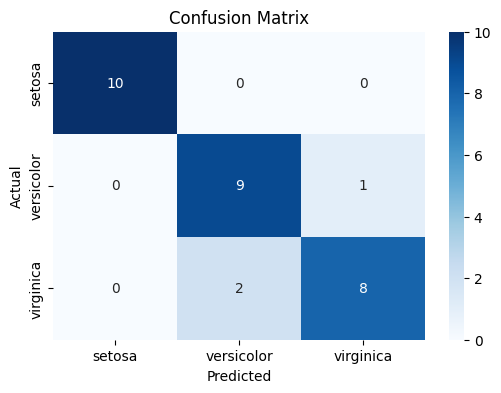

In [29]:
# confusion matrix 시각화
# 실제값 vs 예측값 비교해서 맞춘 개수/틀린 개수를 행렬로 표현
cm = confusion_matrix(y_test, y_pred)  

# 그래프 크기 설정
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,        # 각 칸에 숫자 표시
    cmap='Blues',      # 색상 (진할수록 값이 큼)
    fmt='d',           # 정수 형태로 표시
    xticklabels=class_names,  # 예측 클래스 라벨
    yticklabels=class_names    # 실제 클래스 라벨
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

C:\Users\human3_01\AppData\Local\Temp\ipykernel_11800\1927630342.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_f1, x='class', y='f1', palette='viridis')


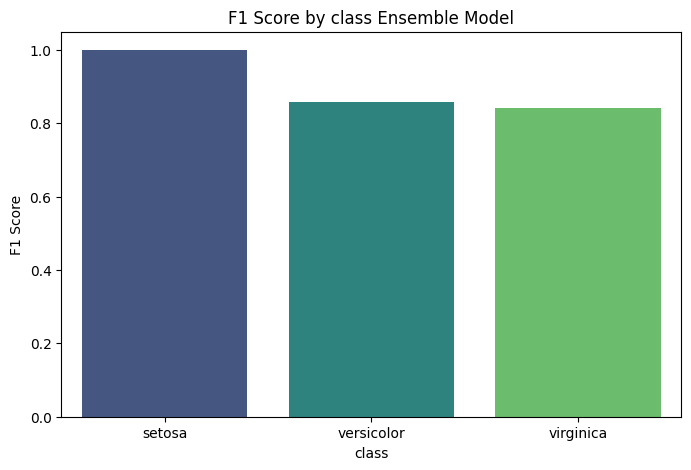

In [34]:
# classification report 생성
# output_dict=True → dict 형태로 반환
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

# class별 f1-score만 추출
# report 딕셔너리에서 각 클래스 이름 기준으로 f1-score만 리스트로 생성
f1_score = [report[c]['f1-score'] for c in class_names]

# 시각화를 위한 DataFrame 생성
# class 이름과 f1-score를 하나의 테이블로 정리
df_f1 = pd.DataFrame({'class': class_names, 'f1': f1_score})
plt.figure(figsize=(8,5))
# palette : 그래프 색깔 테마 지정하는 옵션
sns.barplot(data=df_f1, x='class', y='f1', palette='viridis')

plt.title("F1 Score by class Ensemble Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)   # F1-score 범위 고정 (0 ~ 1.05)

plt.show()

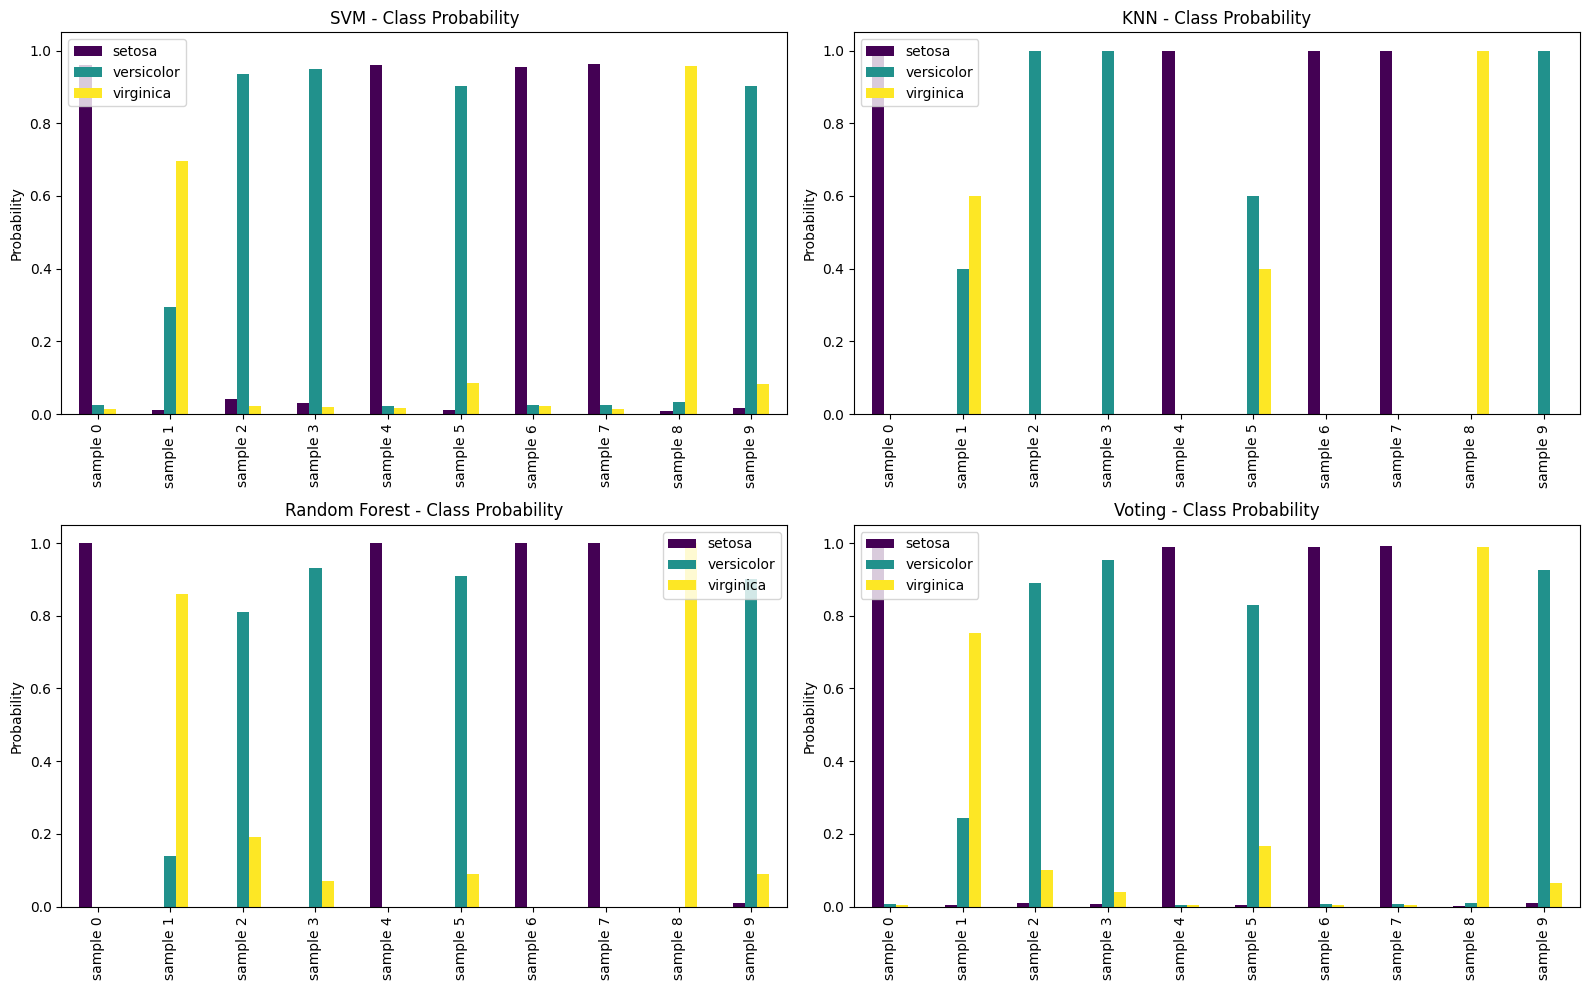

In [39]:
# 0~9번 샘플 인덱스 생성 (테스트 데이터 일부만 사용)
idx = np.arange(10)

# 해당 인덱스의 테스트 데이터와 정답 추출
X_sample = X_test[idx]
y_sample = y_test[idx]

# 각 모델의 예측 확률 계산
proba_svm = svm_clf.predict_proba(X_sample)        # SVM 확률
proba_knn = knn_clf.predict_proba(X_sample)        # KNN 확률
proba_rf = rf_clf.predict_proba(X_sample)          # RandomForest 확률
proba_vote = voting_clf.predict_proba(X_sample)    # Voting 결과 확률

model_names = ["SVM", "KNN", "Random Forest", "Voting"]
proba_list = [proba_svm, proba_knn, proba_rf, proba_vote]

plt.figure(figsize=(16,10))

# 모델별 확률 시각화 (2x2 subplot)
for i, (model_name, proba) in enumerate(zip(model_names, proba_list)):
    plt.subplot(2, 2, i + 1)  # 2x2 그래프 중 i+1번째 위치 선택
    df_prob = pd.DataFrame(proba, columns=class_names)  # 클래스별 확률을 DataFrame으로 변환
    df_prob.index = [f'sample {j}' for j in range(len(df_prob))]  # 샘플 이름 지정
    
    # gca(): "Get Current Axes" → 현재 그리고 있는 그래프 영역(좌표축)을 가져옴
    # 즉, 지금 subplot 위치에 그래프를 그리기 위해 사용
    df_prob.plot(kind="bar", ax=plt.gca(), colormap="viridis")  # 현재 축에 막대그래프 출력

    plt.ylabel("Probability")
    plt.ylim(0, 1.05)
    plt.title(f"{model_name} - Class Probability")

    plt.tight_layout()          # 그래프 간격 자동 조정

plt.show()